# 01 — Exploratory Data Analysis
**Project FORESIGHT · NorthBay Living**

This notebook does two things:
1. Profiles the **raw** extracts to show the data-quality issues *before* cleaning
2. Explores the **cleaned** data to surface demand patterns, seasonality, and movers

Cleaning logic itself lives in `src/pipeline.py` (imported here, not re-implemented) so this notebook and the production pipeline can't drift apart.

In [1]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (9, 4)

## 1. Profile the raw extracts

In [2]:
raw_sales = pd.read_csv('../data/raw/sales_daily.csv')
raw_sku = pd.read_csv('../data/raw/sku_master.csv')
raw_inventory = pd.read_csv('../data/raw/inventory_snapshots.csv')
raw_calendar = pd.read_csv('../data/raw/calendar.csv')

print('sales_daily:', raw_sales.shape)
print('sku_master:', raw_sku.shape)
print('inventory_snapshots:', raw_inventory.shape)
print('calendar:', raw_calendar.shape)
raw_sales.head()

sales_daily: (136929, 6)
sku_master: (204, 6)
inventory_snapshots: (19666, 6)
calendar: (731, 6)


,date,sku_id,units_sold,revenue,unit_price,promo_flag
0,01/01/2024,SKU0001,46,7385.76,160.56,0
1,2024-01-02,SKU0001,6,963.36,160.56,0
2,2024-01-03,SKU0001,0,0.00,160.56,0
3,2024-01-04,SKU0001,0,0.00,160.56,0
4,05-01-2024,SKU0001,0,0.00,160.56,1


### Data-quality issues visible in the raw data

In [3]:
print('--- sales_daily ---')
print('duplicate rows:', raw_sales.duplicated().sum())
print('missing unit_price:', raw_sales['unit_price'].isna().sum())
print('negative units_sold:', (raw_sales['units_sold'] < 0).sum())
print('sample of date formats:', raw_sales['date'].sample(5, random_state=1).tolist())

--- sales_daily ---
duplicate rows: 708
missing unit_price: 4108
negative units_sold: 24
sample of date formats: ['2025-07-20', '2024-02-14', '2025-10-14', '2024-06-03', '21-12-2025']


In [4]:
print('--- sku_master ---')
print('duplicate sku_id rows:', raw_sku.duplicated(subset='sku_id').sum())
print('missing unit_cost:', raw_sku['unit_cost'].isna().sum())
print('raw category label variants:', sorted(raw_sku['category'].unique()))

--- sku_master ---
duplicate sku_id rows: 4
missing unit_cost: 10
raw category label variants: ['DECOR ', 'Decor', 'Décor', 'FURNITURE', 'Furnitur', 'Furniture', 'Home Decor', 'LIGHTING', 'Lighting', 'Lighting ', 'SMALL APPLIANCES', 'Small Appliance', 'Small Appliances', 'TEXTILES', 'Textile', 'Textiles', 'decor', 'furniture', 'lighting', 'small appliances', 'textiles']


In [5]:
print('--- inventory_snapshots ---')
print('duplicate (date, sku_id) rows:', raw_inventory.duplicated(subset=['date','sku_id']).sum())
print('missing on_order_units:', raw_inventory['on_order_units'].isna().sum())

--- inventory_snapshots ---
duplicate (date, sku_id) rows: 195
missing on_order_units: 392


**Takeaway:** duplicates, inconsistent category labels, mixed date formats, missing values, and a few outliers are all present — exactly what a real client export looks like. All of this is fixed programmatically in `src/pipeline.py` with every decision logged to `data/processed/data_quality_log.json`.

## 2. Load the cleaned, analysis-ready data

In [6]:
df = pd.read_parquet('../data/processed/analysis_ready.parquet')
df['date'] = pd.to_datetime(df['date'])
print(df.shape)
print('date range:', df['date'].min().date(), '->', df['date'].max().date())
print('categories (post-clean):', sorted(df['category'].unique()))
df.head()

(136175, 27)
date range: 2024-01-01 -> 2025-12-31
categories (post-clean): ['Decor', 'Furniture', 'Lighting', 'Small Appliances', 'Textiles']


,date,sku_id,units_sold,revenue,unit_price,promo_flag,category,subcategory,launch_date,unit_cost,list_price,week,month,season,is_holiday,promo_event,dow,is_weekend,week_of_year,is_promo,lag_7,lag_14,lag_28,roll_mean_7,roll_mean_28,roll_std_28,sku_age_days
0,2024-01-01,SKU0001,46.0,7385.76,160.56,0,Furniture,Shelving,2023-07-12,106.12,160.56,1,1,Winter,1,NaN,0,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,173
1,2024-01-02,SKU0001,6.0,963.36,160.56,0,Furniture,Shelving,2023-07-12,106.12,160.56,1,1,Winter,0,NaN,1,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,174
2,2024-01-03,SKU0001,0.0,0.00,160.56,0,Furniture,Shelving,2023-07-12,106.12,160.56,1,1,Winter,0,NaN,2,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,175
3,2024-01-04,SKU0001,0.0,0.00,160.56,0,Furniture,Shelving,2023-07-12,106.12,160.56,1,1,Winter,0,NaN,3,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,176
4,2024-01-05,SKU0001,25.0,4014.00,160.56,0,Furniture,Shelving,2023-07-12,106.12,160.56,1,1,Winter,0,New Year Sale,4,0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,177


## 3. Demand trend

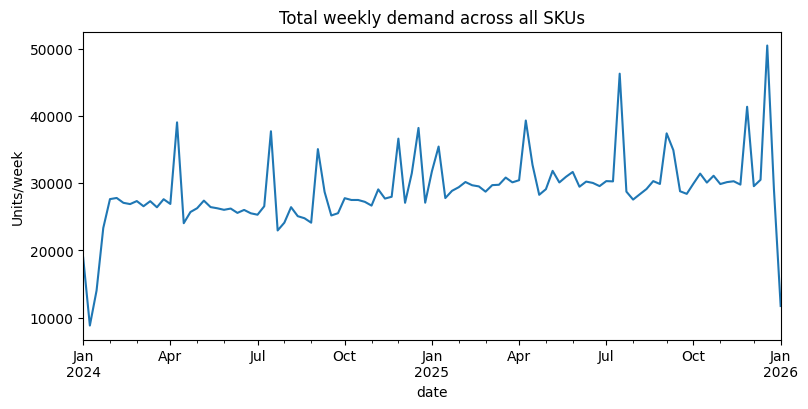

peak week: 2025-12-21 50444.0
trough week: 2024-01-14 8831.0


In [7]:
weekly = df.set_index('date').resample('W')['units_sold'].sum()
weekly.plot(title='Total weekly demand across all SKUs', ylabel='Units/week')
plt.show()
print('peak week:', weekly.idxmax().date(), weekly.max())
print('trough week:', weekly.idxmin().date(), weekly.min())

## 4. Seasonality by category

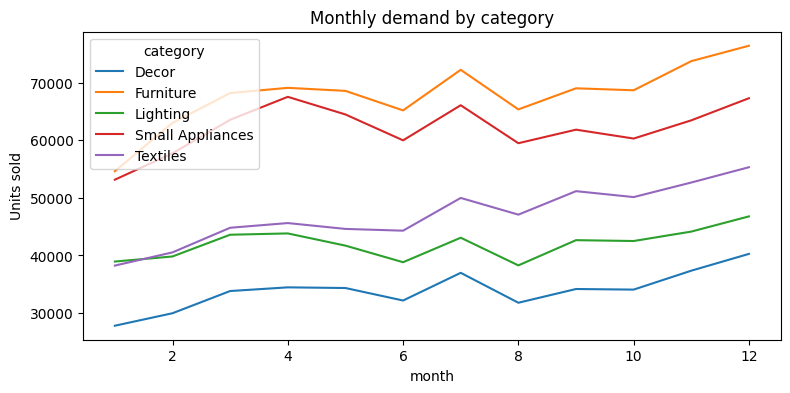

most seasonal category (highest std across months): Furniture


In [8]:
monthly_cat = (df.assign(month=df['date'].dt.month)
                 .groupby(['month','category'])['units_sold'].sum()
                 .unstack('category'))
monthly_cat.plot(title='Monthly demand by category')
plt.ylabel('Units sold')
plt.show()
print('most seasonal category (highest std across months):', monthly_cat.std().idxmax())

## 5. Top / bottom movers

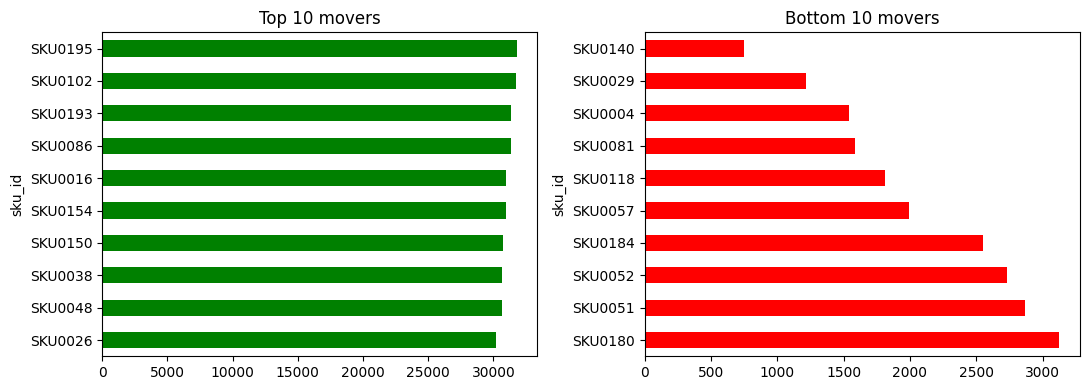

In [9]:
totals = df.groupby('sku_id')['units_sold'].sum().sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
totals.head(10)[::-1].plot.barh(ax=axes[0], color='green', title='Top 10 movers')
totals.tail(10).plot.barh(ax=axes[1], color='red', title='Bottom 10 movers')
plt.tight_layout()
plt.show()

## 6. Promotion & calendar effects

In [10]:
promo_avg = df.groupby('is_promo')['units_sold'].mean()
print('avg units/day, non-promo vs promo:', promo_avg.values)
print(f"promo lift: {(promo_avg[1]/promo_avg[0]-1)*100:.1f}%")

weekend_avg = df.groupby('is_weekend')['units_sold'].mean()
print('avg units/day, weekday vs weekend:', weekend_avg.values)

avg units/day, non-promo vs promo: [21.20451532 33.0631545 ]
promo lift: 55.9%
avg units/day, weekday vs weekend: [21.09692184 25.26987522]


In [11]:
corr_cols = ['units_sold', 'is_promo', 'is_weekend', 'is_holiday', 'unit_price']
df[corr_cols].corr(numeric_only=True)['units_sold'].sort_values(ascending=False)

units_sold    1.000000
is_promo      0.197678
is_weekend    0.109074
is_holiday    0.027737
unit_price   -0.049450
Name: units_sold, dtype: float64

## 7. Revenue by category

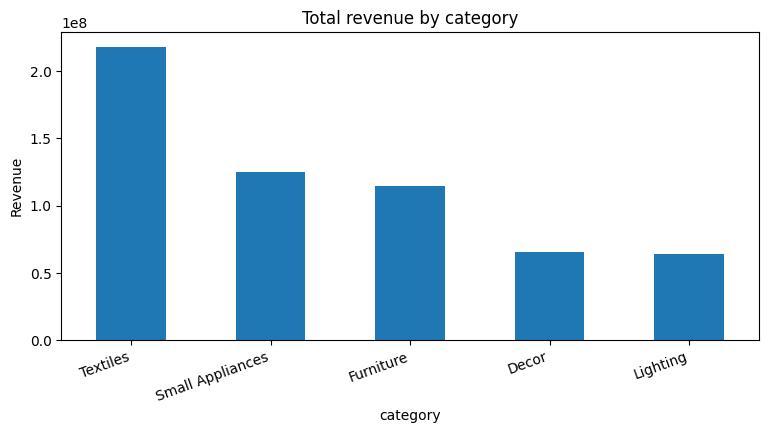

category
Textiles            2.181494e+08
Small Appliances    1.248396e+08
Furniture           1.147609e+08
Decor               6.579187e+07
Lighting            6.406540e+07
Name: revenue, dtype: float64

In [12]:
cat_rev = df.groupby('category')['revenue'].sum().sort_values(ascending=False)
cat_rev.plot.bar(title='Total revenue by category', ylabel='Revenue')
plt.xticks(rotation=20, ha='right')
plt.show()
cat_rev

## Summary — findings carried into the memo & modelling
- Demand trends upward over the window with clear promo/holiday spikes
- Seasonality is category-specific (not a single business-wide pattern) — the model needs category-aware or per-SKU seasonality, not one flat seasonal curve
- Promotions produce a real, quantifiable lift — must be a model feature (`is_promo`), not left for the model to guess
- No SKU is truly dead — 'bottom movers' still sell, just slower — supports treating overstock as a *rate* problem, not a discontinue-immediately problem
- Data-quality issues were all fixable without material data loss — proceed to modelling with confidence in `analysis_ready.parquet`